In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import lightgbm as lgb
import xgboost as xgb
from fastapi import FastAPI

print("All packages imported successfully!")

All packages imported successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data/raw/yahoo_stock.csv', parse_dates=['Date'])
df = df.sort_values('Date').set_index('Date')

print("Shape:", df.shape)
print("\nDate range:", df.index.min(), "→", df.index.max())
print("\nNull values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (1825, 6)

Date range: 2015-11-23 00:00:00 → 2020-11-20 00:00:00

Null values:
 High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64

First 5 rows:


,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


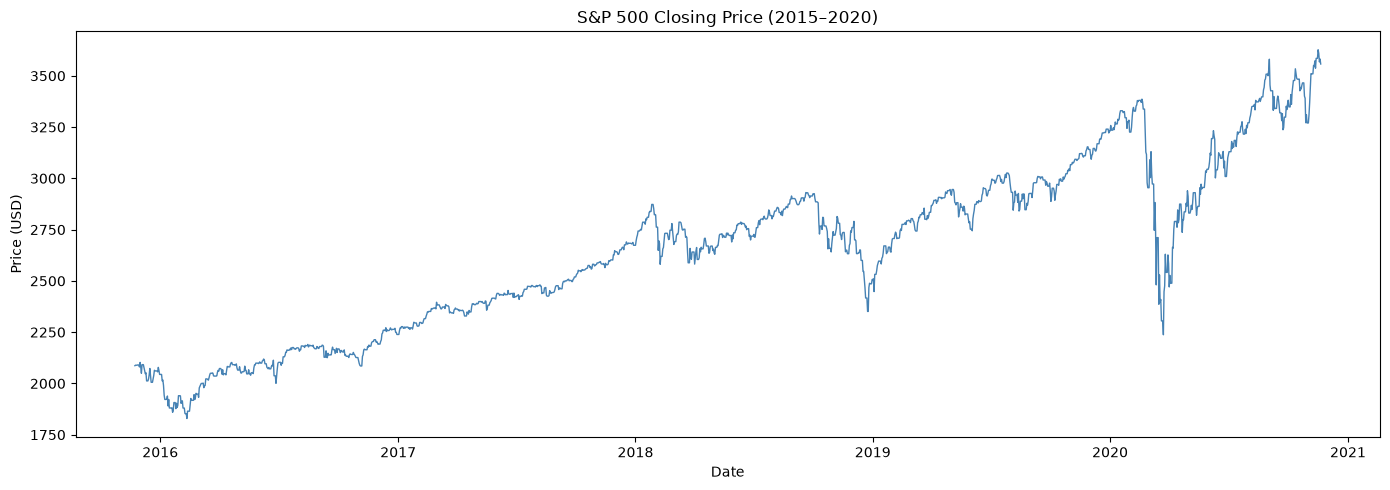

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], color='steelblue', linewidth=1)
plt.title('S&P 500 Closing Price (2015–2020)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'].dropna())
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')

if result[1] > 0.05:
    print("\nResult: NON-STATIONARY → we need to difference the series")
else:
    print("\nResult: STATIONARY → ready to model") 

ADF Statistic : -0.8704
p-value       : 0.7976

Result: NON-STATIONARY → we need to difference the series


After differencing:
ADF Statistic : -8.5222
p-value       : 0.0000


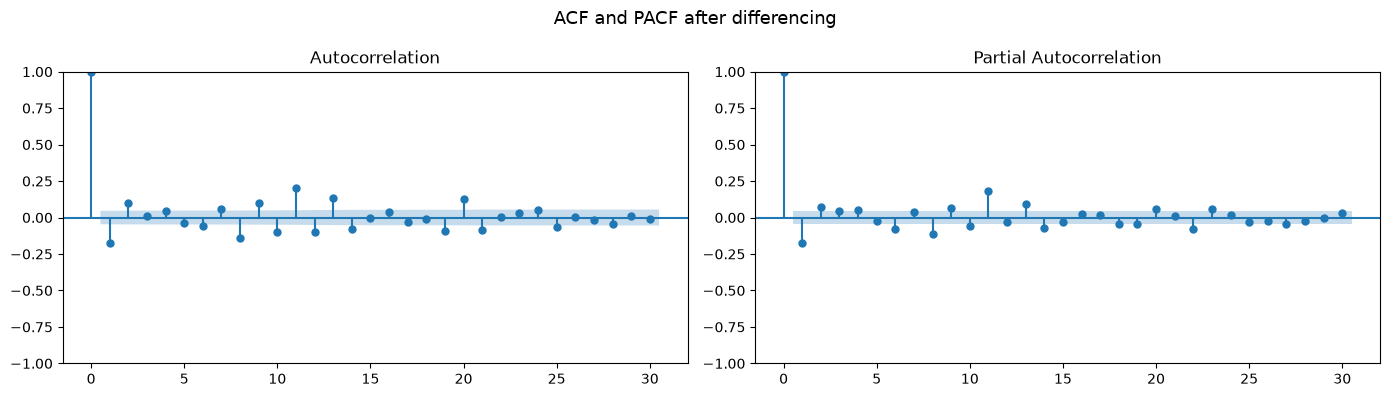

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Difference the series to make it stationary
df['Close_diff'] = df['Close'].diff()

# Confirm it's now stationary
result2 = adfuller(df['Close_diff'].dropna())
print(f'After differencing:')
print(f'ADF Statistic : {result2[0]:.4f}')
print(f'p-value       : {result2[1]:.4f}')

# Plot ACF and PACF — these tell us ARIMA parameters
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['Close_diff'].dropna(), lags=30, ax=axes[0])
plot_pacf(df['Close_diff'].dropna(), lags=30, ax=axes[1])
plt.suptitle('ACF and PACF after differencing', fontsize=13)
plt.tight_layout()
plt.show() 

C:\Users\Deepak Sah\forecasting-project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Deepak Sah\forecasting-project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Deepak Sah\forecasting-project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA(1,1,1) Results:
MAPE : 4.41%
RMSE : 182.06


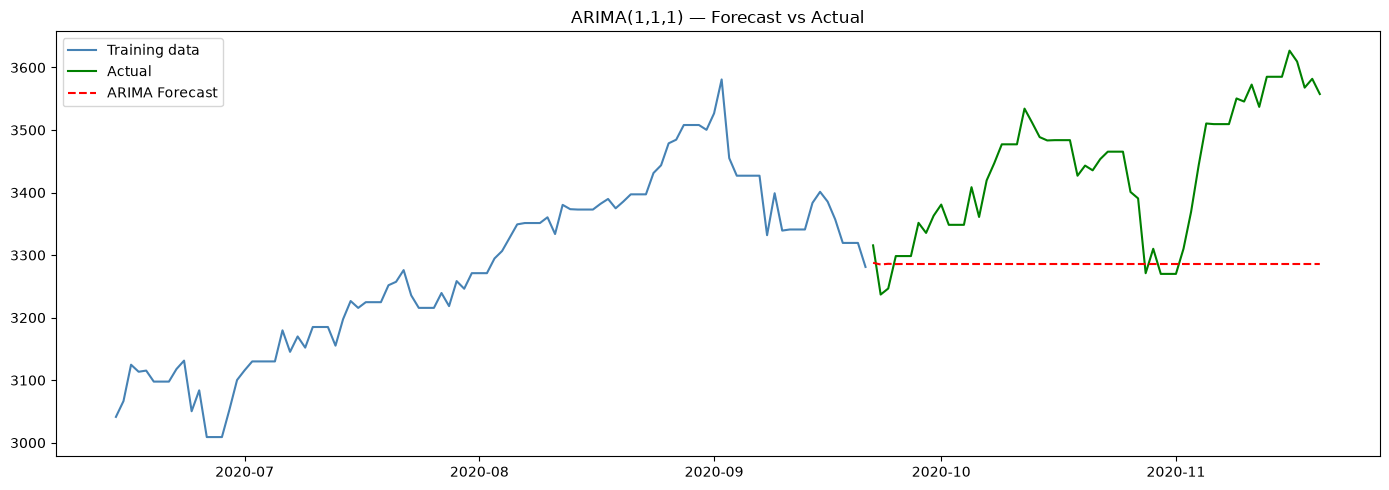

In [6]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

# Train/test split — last 60 days as test
train = df['Close'][:-60]
test  = df['Close'][-60:]

# Fit ARIMA(1,1,1)
model = ARIMA(train, order=(1, 1, 1))
fitted = model.fit()

# Forecast 60 days
forecast = fitted.forecast(steps=60)

# Metrics
mape = mean_absolute_percentage_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f'ARIMA(1,1,1) Results:')
print(f'MAPE : {mape:.2%}')
print(f'RMSE : {rmse:.2f}')

# Plot forecast vs actual
plt.figure(figsize=(14, 5))
plt.plot(train[-100:], label='Training data', color='steelblue')
plt.plot(test, label='Actual', color='green')
plt.plot(test.index, forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA(1,1,1) — Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000703 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1805
[LightGBM] [Info] Number of data points in the train set: 1755, number of used features: 9
[LightGBM] [Info] Start training from score 2624.125128
LightGBM Results:
MAPE : 1.68%
RMSE : 73.50


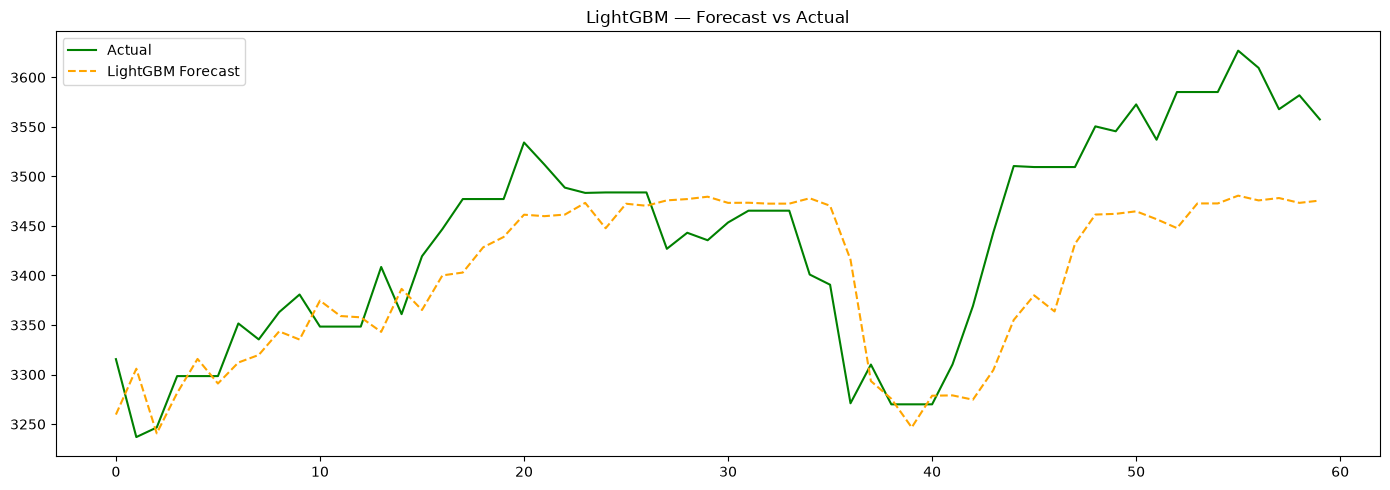

In [7]:
import lightgbm as lgb

# Feature engineering
df2 = df[['Close']].copy()
df2['lag_1']  = df2['Close'].shift(1)
df2['lag_2']  = df2['Close'].shift(2)
df2['lag_5']  = df2['Close'].shift(5)
df2['lag_10'] = df2['Close'].shift(10)
df2['rolling_mean_5']  = df2['Close'].rolling(5).mean()
df2['rolling_mean_10'] = df2['Close'].rolling(10).mean()
df2['rolling_std_5']   = df2['Close'].rolling(5).std()
df2['month']      = df2.index.month
df2['dayofweek']  = df2.index.dayofweek
df2 = df2.dropna()

# Train/test split
features = ['lag_1','lag_2','lag_5','lag_10',
            'rolling_mean_5','rolling_mean_10','rolling_std_5',
            'month','dayofweek']
X_train = df2[features][:-60]
y_train = df2['Close'][:-60]
X_test  = df2[features][-60:]
y_test  = df2['Close'][-60:]

# Train model
model_lgb = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05)
model_lgb.fit(X_train, y_train)
preds_lgb = model_lgb.predict(X_test)

# Metrics
mape_lgb = mean_absolute_percentage_error(y_test, preds_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, preds_lgb))
print(f'LightGBM Results:')
print(f'MAPE : {mape_lgb:.2%}')
print(f'RMSE : {rmse_lgb:.2f}')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual', color='green')
plt.plot(preds_lgb, label='LightGBM Forecast', color='orange', linestyle='--')
plt.title('LightGBM — Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Final comparison table
results = {
    'Model':  ['ARIMA(1,1,1)', 'LightGBM'],
    'MAPE':   [f'4.41%',       f'1.68%'],
    'RMSE':   [f'182.06',      f'73.50'],
    'Notes':  ['Statistical baseline, flat forecast',
               'Lag features + rolling stats, follows trend well']
}

results_df = pd.DataFrame(results)
print("=" * 65)
print("        MODEL COMPARISON — S&P 500 Forecasting")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)
print("\nConclusion: LightGBM outperforms ARIMA by 2.6x on MAPE")
print("Winner: LightGBM (1.68% MAPE vs 4.41%)")

# Save results
import joblib
joblib.dump(model_lgb, 'models/lgbm_forecast.pkl')
print("\nModel saved to models/lgbm_forecast.pkl")

        MODEL COMPARISON — S&P 500 Forecasting
       Model  MAPE   RMSE                                            Notes
ARIMA(1,1,1) 4.41% 182.06              Statistical baseline, flat forecast
    LightGBM 1.68%  73.50 Lag features + rolling stats, follows trend well

Conclusion: LightGBM outperforms ARIMA by 2.6x on MAPE
Winner: LightGBM (1.68% MAPE vs 4.41%)

Model saved to models/lgbm_forecast.pkl
